# Prior vs UCB Examples

## GP Bernoulli Probability Surface

Imagine a manufacturing process where you can choose two control settings x = (temperature, pressure).
Each run returns a binary outcome: y=1 means "defect-free", y=0 means "defective".
We want to find settings that maximize the success probability with as few trials as possible.

We assume *binary* (success/failure) model outputs, so we model a success probability surface
$$
p(x)=\mathbb{P}(y=1\mid x), \qquad x\in\mathbb{R}^2.
$$

**Latent GP model.** We introduce a latent real-valued function $f(x)$ and a logistic link:
- Prior: $f \sim \mathcal{GP}(m, k)$ ($k$ is an RBF kernel).
- Likelihood:
$$
p(y\mid f(X))=\prod_{i=1}^n \sigma\bigl(f(x_i)\bigr)^{y_i}\,\bigl(1-\sigma\bigl(f(x_i)\bigr)\bigr)^{1-y_i},
\qquad \sigma(z)=\frac{1}{1+e^{-z}}.
$$

Key point: with a logistic link, the posterior is NOT Gaussian, so the MAP is not closed-form.

### Exploration using a high expectation acquisition function

The MAP is given by Bayes' rule (ignoring the normalizing constant):

$$
f_{\mathrm{MAP}}=\arg\max_f \log p(f\mid X,y)
=\arg\min_f\Bigl[-\log p(y\mid f(X)) - \log p(f)\Bigr].
$$

Due to the well known connection between Gaussian Processes and Kernel Methods, we can
make use of the representer theorem for MAP calculation. In particular, since the likelihood depends on $f$
only through point evaluations $f(x_1),\dots,f(x_n)$, any minimizer admits a representation of the form:

$$
f(x)=m(x) +\sum_{j=1}^n \beta_j\, k\bigl(x_j, x\bigr).
$$

Substituting this back into the MAP objective yields a finite-dimensional optimization in $\beta\in\mathbb{R}^n$ (up to additive constants):

$$
\beta_{\mathrm{MAP}}=\arg\min_{\beta\in\mathbb{R}^n}\left\{
\frac12\,\beta^{\top}K\,\beta
-\sum_{t=1}^n\Bigl[y_t\log\sigma(g_t) + (1-y_t)\log\bigl(1-\sigma(g_t)\bigr)\Bigr]
\right\},
$$

where $K\in\mathbb{R}^{n\times n}$ is the Gram matrix $K_{ij}=k(x_i,x_j)$ and $g_t=f(x_t)=m(x_t) + (K\beta)_t$.

Setting a high fixed $m(x)$ makes the sampling explore when sampling the maximum from the posterior.

### Exploration using GP UCB

In standard GP regression with a Gaussian likelihood, the posterior over $f$ is again a GP with a closed-form mean and variance:
$$
\mu_n(x)=\mathbb{E}[f(x)\mid \mathcal{D}_n], \qquad s_n^2(x)=\mathrm{Var}(f(x)\mid \mathcal{D}_n).
$$
As usual in GP-UCB we assume a zero prior mean $m(x)=0$ (or equivalently we work with the centered latent $f(x)-m(x)$).

The GP-UCB acquisition function then trades off exploitation and exploration via
$$
a_{\mathrm{UCB}}(x)=\mu_n(x) + \sqrt{\beta_n}\, s_n(x),
\qquad x_{n+1}=\arg\max_{x\in\mathcal{X}} a_{\mathrm{UCB}}(x).
$$

In our Bernoulli (logistic-link) model the posterior $p(f\mid \mathcal{D}_n)$ is not Gaussian, so $\mu_n(x)$ and $s_n^2(x)$ are not available in closed form.
In practice we use an inducing-point variational approximation (SVGP), which yields an approximately Gaussian marginal for the latent $f(x)$ at candidate points.
You can then plug the resulting approximate mean and standard deviation into the same UCB formula above.

If you prefer to run UCB directly on the success probability $p(x)=\sigma(f(x))$, a simple monotone transform often used in practice is
$$
a^{(p)}_{\mathrm{UCB}}(x)=\sigma\bigl(\mu_n(x) + \sqrt{\beta_n}\, s_n(x)\bigr),
$$
which is an “optimistic” probability estimate under the Gaussian latent approximation.

The parameter $\beta_n$ controls how aggressively to explore: larger values emphasize high-uncertainty regions, smaller values behave more greedily.

In [1]:
import numpy as np

# Sampling parameters
T = 200

# Common GP parameters
length_scale = 0.7
variance = 1.0
noise = 0.35


def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


def rbf_kernel(Xa, Xb):
    Xa2 = np.sum(Xa**2, axis=1)[:, None]
    Xb2 = np.sum(Xb**2, axis=1)[None, :]
    sqdist = Xa2 + Xb2 - 2.0 * Xa @ Xb.T
    return variance * np.exp(-0.5 * sqdist / (length_scale**2))


def latent_true(X):
    x1 = X[:, 0]
    x2 = X[:, 1]
    # Smooth multimodal latent surface on which Bernoulli outcomes are sampled.
    return (
        1.8 * np.exp(-((x1 - 0.7) ** 2 + (x2 + 0.8) ** 2) / 0.5)
        + 1.5 * np.exp(-((x1 + 1.1) ** 2 + (x2 - 0.6) ** 2) / 0.7)
        - 1.2
    )


# Candidate domain in R^2 (temperature, pressure).
x1 = np.linspace(-2.0, 2.0, 100)
x2 = np.linspace(-2.0, 2.0, 100)
X1, X2 = np.meshgrid(x1, x2)
X_cand = np.column_stack([X1.ravel(), X2.ravel()])
P_true_grid = sigmoid(latent_true(X_cand))

rng = np.random.default_rng(7)
n_init = 12
idx0 = rng.choice(X_cand.shape[0], size=n_init, replace=False)
X_init = X_cand[idx0]
y_init = rng.binomial(1, sigmoid(latent_true(X_init))).astype(float)


print(f"Candidates: {X_cand.shape[0]}")
print(f"Initial observations: {n_init}")
print(f"Initial empirical success rate: {y_init.mean():.3f}")

Candidates: 10000
Initial observations: 12
Initial empirical success rate: 0.250


In [2]:
# Technique 1: high fixed expectation + posterior sampling around MAP (Laplace in beta-space)

def fit_beta_map_laplace(X_obs, y_obs, m_high, jitter=1e-6, max_iter=20):
    n = X_obs.shape[0]
    K = rbf_kernel(X_obs, X_obs)
    K = K + jitter * np.eye(n)

    beta = np.zeros(n)
    for _ in range(max_iter):
        g = m_high + K @ beta
        p = sigmoid(g)

        grad = K @ beta + K @ (p - y_obs)
        W = p * (1.0 - p)
        H = K + (K * W[None, :]) @ K + jitter * np.eye(n)

        step = np.linalg.solve(H, grad)
        beta_next = beta - step
        if np.linalg.norm(beta_next - beta) < 1e-7:
            beta = beta_next
            break
        beta = beta_next

    g = m_high + K @ beta
    p = sigmoid(g)
    W = p * (1.0 - p)
    H = K + (K * W[None, :]) @ K + jitter * np.eye(n)
    return beta, H


m_high = 1.4
rng_he = np.random.default_rng(2026)

X_obs = X_init.copy()
y_obs = y_init.copy()
chosen = set(idx0.tolist())

for _ in range(T):
    beta_map, H = fit_beta_map_laplace(X_obs, y_obs, m_high)
    Kxs = rbf_kernel(X_obs, X_cand)

    L = np.linalg.cholesky(H)
    z = rng_he.standard_normal(beta_map.shape[0])
    beta_sample = beta_map + np.linalg.solve(L.T, z)

    f_sample = m_high + Kxs.T @ beta_sample
    f_sample[list(chosen)] = -np.inf

    i = int(np.argmax(f_sample))
    x_next = X_cand[i]
    y_next = rng_he.binomial(1, sigmoid(latent_true(x_next[None, :]))[0])

    X_obs = np.vstack([X_obs, x_next])
    y_obs = np.append(y_obs, float(y_next))
    chosen.add(i)

p_visited_he = sigmoid(latent_true(X_obs))
best_idx_he = int(np.argmax(p_visited_he))

results_high_expectation = {
    "best_true_prob": float(p_visited_he[best_idx_he]),
    "best_x": X_obs[best_idx_he],
    "observed_success_rate": float(y_obs.mean()),
    "num_points": int(X_obs.shape[0]),
}

print("High-expectation exploration:")
print(results_high_expectation)

High-expectation exploration:
{'best_true_prob': 0.6418874352995434, 'best_x': array([ 0.70707071, -0.86868687]), 'observed_success_rate': 0.3584905660377358, 'num_points': 212}


In [3]:
# Technique 2: GP-UCB with zero-mean GP regression surrogate
beta_n = 9.0

def gp_regression_posterior(X_train, y_train, X_test, jitter=1e-8):
    n = X_train.shape[0]
    K = rbf_kernel(X_train, X_train)
    K = K + (noise**2 + jitter) * np.eye(n)

    Ks = rbf_kernel(X_train, X_test)
    Kss_diag = np.full(X_test.shape[0], variance)

    L = np.linalg.cholesky(K)
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, y_train))
    mu = Ks.T @ alpha

    v = np.linalg.solve(L, Ks)
    var = np.maximum(Kss_diag - np.sum(v * v, axis=0), 1e-12)
    return mu, var


# Larger beta_n gives a stronger uncertainty bonus and therefore more exploration.
rng_ucb = np.random.default_rng(2027)

X_obs = X_init.copy()
y_obs = y_init.copy()
chosen = set(idx0.tolist())

for _ in range(T):
    mu_f, var_f = gp_regression_posterior(X_obs, y_obs, X_cand)
    s_f = np.sqrt(var_f)

    a_ucb = mu_f + np.sqrt(beta_n) * s_f
    a_ucb[list(chosen)] = -np.inf

    i = int(np.argmax(a_ucb))
    x_next = X_cand[i]
    y_next = rng_ucb.binomial(1, sigmoid(latent_true(x_next[None, :]))[0])

    X_obs = np.vstack([X_obs, x_next])
    y_obs = np.append(y_obs, float(y_next))
    chosen.add(i)

p_visited_ucb = sigmoid(latent_true(X_obs))
best_idx_ucb = int(np.argmax(p_visited_ucb))

results_ucb = {
    "best_true_prob": float(p_visited_ucb[best_idx_ucb]),
    "best_x": X_obs[best_idx_ucb],
    "observed_success_rate": float(y_obs.mean()),
    "num_points": int(X_obs.shape[0]),
}

print("GP-UCB exploration:")
print(results_ucb)

print("\nComparison:")
print({
    "high_expectation_best_true_prob": results_high_expectation["best_true_prob"],
    "ucb_best_true_prob": results_ucb["best_true_prob"],
})

GP-UCB exploration:
{'best_true_prob': 0.6265710961861367, 'best_x': array([ 0.54545455, -0.78787879]), 'observed_success_rate': 0.3160377358490566, 'num_points': 212}

Comparison:
{'high_expectation_best_true_prob': 0.6418874352995434, 'ucb_best_true_prob': 0.6265710961861367}


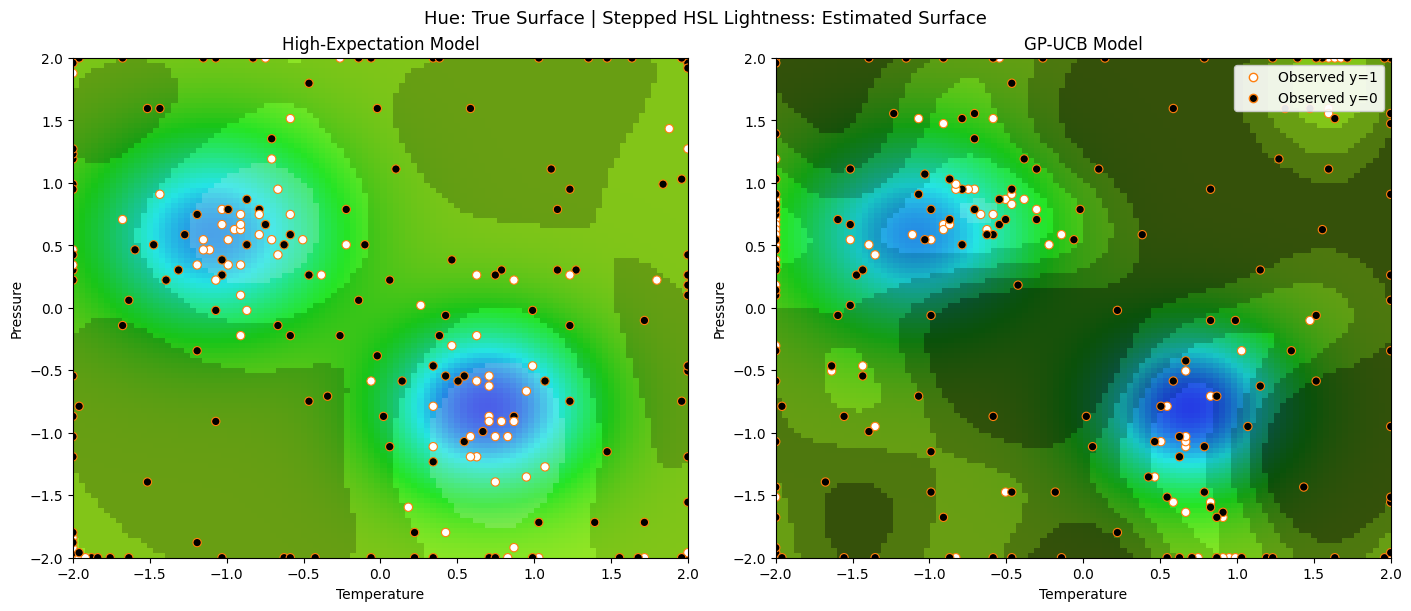

In [4]:
import colorsys
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# Re-run both strategies with fixed seeds to recover full sampled paths for plotting.
def run_high_expectation_path(seed=2026):
    rng_local = np.random.default_rng(seed)
    X_obs = X_init.copy()
    y_obs = y_init.copy()
    chosen = set(idx0.tolist())

    for _ in range(T):
        beta_map, H = fit_beta_map_laplace(X_obs, y_obs, m_high)
        Kxs = rbf_kernel(X_obs, X_cand)

        L = np.linalg.cholesky(H)
        z = rng_local.standard_normal(beta_map.shape[0])
        beta_sample = beta_map + np.linalg.solve(L.T, z)

        f_sample = m_high + Kxs.T @ beta_sample
        f_sample[list(chosen)] = -np.inf

        i = int(np.argmax(f_sample))
        x_next = X_cand[i]
        y_next = rng_local.binomial(1, sigmoid(latent_true(x_next[None, :]))[0])

        X_obs = np.vstack([X_obs, x_next])
        y_obs = np.append(y_obs, float(y_next))
        chosen.add(i)

    beta_map_final, _ = fit_beta_map_laplace(X_obs, y_obs, m_high)
    p_est = sigmoid(m_high + rbf_kernel(X_obs, X_cand).T @ beta_map_final)
    return X_obs, y_obs, p_est


def run_ucb_path(seed=2027):
    rng_local = np.random.default_rng(seed)
    X_obs = X_init.copy()
    y_obs = y_init.copy()
    chosen = set(idx0.tolist())

    for _ in range(T):
        mu_f, var_f = gp_regression_posterior(X_obs, y_obs, X_cand)
        s_f = np.sqrt(var_f)

        a_ucb = mu_f + np.sqrt(beta_n) * s_f
        a_ucb[list(chosen)] = -np.inf

        i = int(np.argmax(a_ucb))
        x_next = X_cand[i]
        y_next = rng_local.binomial(1, sigmoid(latent_true(x_next[None, :]))[0])

        X_obs = np.vstack([X_obs, x_next])
        y_obs = np.append(y_obs, float(y_next))
        chosen.add(i)

    mu_f_final, _ = gp_regression_posterior(X_obs, y_obs, X_cand)
    p_est = np.clip(mu_f_final, 0.0, 1.0)
    return X_obs, y_obs, p_est


def _quantize_01(values, n_steps):
    n_steps = max(2, int(n_steps))
    return np.round(np.clip(values, 0.0, 1.0) * (n_steps - 1)) / (n_steps - 1)


def hue_lightness_composite(p_true, p_est, n_light_steps=9):
    # HSL lets us keep hue from truth while using stepped lightness for estimate.
    h = np.clip(p_true, 0.0, 1.0)
    l_min, l_max = 0.18, 0.86
    l = l_min + (l_max - l_min) * np.clip(p_est, 0.0, 1.0)
    l = l_min + (l_max - l_min) * _quantize_01((l - l_min) / (l_max - l_min), n_light_steps)
    s = np.full_like(h, 0.78)

    h_flat = h.ravel()
    l_flat = l.ravel()
    s_flat = s.ravel()
    rgb_flat = np.array(
        [colorsys.hls_to_rgb(float(hh), float(ll), float(ss)) for hh, ll, ss in zip(h_flat, l_flat, s_flat)],
        dtype=float,
    )
    return rgb_flat.reshape(h.shape + (3,))


X_he, y_he, p_est_he = run_high_expectation_path(seed=2026)
X_ucb, y_ucb, p_est_ucb = run_ucb_path(seed=2027)

p_true_grid = P_true_grid.reshape(X1.shape)
p_est_he_grid = p_est_he.reshape(X1.shape)
p_est_ucb_grid = p_est_ucb.reshape(X1.shape)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
extent = [x1.min(), x1.max(), x2.min(), x2.max()]

plot_specs = [
    (axes[0], p_est_he_grid, X_he, y_he, "High-Expectation Model"),
    (axes[1], p_est_ucb_grid, X_ucb, y_ucb, "GP-UCB Model"),
]

for ax, p_est_grid, X_s, y_s, title in plot_specs:
    rgb = hue_lightness_composite(p_true_grid, p_est_grid, n_light_steps=9)
    ax.imshow(rgb, origin="lower", extent=extent, aspect="auto")

    point_colors = np.where(y_s > 0.5, "white", "black")
    ax.scatter(
        X_s[:, 0],
        X_s[:, 1],
        c=point_colors,
        s=36,
        edgecolors="tab:orange",
        linewidths=0.8,
    )

    ax.set_title(title)
    ax.set_xlabel("Temperature")
    ax.set_ylabel("Pressure")

legend_handles = [
    Line2D([0], [0], marker="o", linestyle="none", markerfacecolor="white", markeredgecolor="tab:orange", label="Observed y=1"),
    Line2D([0], [0], marker="o", linestyle="none", markerfacecolor="black", markeredgecolor="tab:orange", label="Observed y=0"),
]
axes[1].legend(handles=legend_handles, loc="upper right", framealpha=0.9)

fig.suptitle("Hue: True Surface | Stepped HSL Lightness: Estimated Surface", fontsize=13)
plt.show()

In [5]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots


# Build the same estimated surfaces used in the 2D comparison.
X_he_3d, y_he_3d, p_est_he_3d = run_high_expectation_path(seed=2026)
X_ucb_3d, y_ucb_3d, p_est_ucb_3d = run_ucb_path(seed=2027)

p_true_grid_3d = P_true_grid.reshape(X1.shape)
p_est_he_grid_3d = p_est_he_3d.reshape(X1.shape)
p_est_ucb_grid_3d = p_est_ucb_3d.reshape(X1.shape)

# Small lift avoids z-fighting artifacts when two surfaces are very close.
z_lift = 1e-3

fig = make_subplots(
    rows=1,
    cols=2,
    specs=[[{"type": "scene"}, {"type": "scene"}]],
    subplot_titles=("3D Surfaces: High-Expectation", "3D Surfaces: GP-UCB"),
    horizontal_spacing=0.04,
)


def add_surface(z_surface, color, name, row, col, opacity, showlegend):
    fig.add_trace(
        go.Surface(
            x=X1,
            y=X2,
            z=z_surface,
            colorscale=[[0.0, color], [1.0, color]],
            cmin=0.0,
            cmax=1.0,
            showscale=False,
            opacity=opacity,
            name=name,
            showlegend=showlegend,
            lighting=dict(ambient=0.32, diffuse=0.90, specular=0.28, roughness=0.58, fresnel=0.10),
            lightposition=dict(x=220, y=180, z=260),
            hovertemplate="Temperature=%{x:.2f}<br>Pressure=%{y:.2f}<br>Probability=%{z:.3f}<extra>" + name + "</extra>",
        ),
        row=row,
        col=col,
    )


# Left panel: true surface + high-expectation estimate.
add_surface(p_true_grid_3d + z_lift, "royalblue", "True surface", row=1, col=1, opacity=1.0, showlegend=True)
add_surface(p_est_he_grid_3d, "tomato", "High-Expectation estimate", row=1, col=1, opacity=1.0, showlegend=True)

# Right panel: true surface + GP-UCB estimate.
add_surface(p_true_grid_3d + z_lift, "royalblue", "True surface", row=1, col=2, opacity=1.0, showlegend=False)
add_surface(p_est_ucb_grid_3d, "seagreen", "GP-UCB estimate", row=1, col=2, opacity=1.0, showlegend=True)

# Sampled points: white for y=1, black for y=0.
mask_he_pos = y_he_3d > 0.5
mask_ucb_pos = y_ucb_3d > 0.5

fig.add_trace(
    go.Scatter3d(
        x=X_he_3d[mask_he_pos, 0],
        y=X_he_3d[mask_he_pos, 1],
        z=y_he_3d[mask_he_pos],
        mode="markers",
        marker=dict(size=4, color="white", line=dict(color="orange", width=2)),
        name="Observed y=1",
        showlegend=True,
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter3d(
        x=X_he_3d[~mask_he_pos, 0],
        y=X_he_3d[~mask_he_pos, 1],
        z=y_he_3d[~mask_he_pos],
        mode="markers",
        marker=dict(size=4, color="black", line=dict(color="orange", width=2)),
        name="Observed y=0",
        showlegend=True,
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter3d(
        x=X_ucb_3d[mask_ucb_pos, 0],
        y=X_ucb_3d[mask_ucb_pos, 1],
        z=y_ucb_3d[mask_ucb_pos],
        mode="markers",
        marker=dict(size=4, color="white", line=dict(color="orange", width=2)),
        name="Observed y=1",
        showlegend=False,
    ),
    row=1,
    col=2,
)
fig.add_trace(
    go.Scatter3d(
        x=X_ucb_3d[~mask_ucb_pos, 0],
        y=X_ucb_3d[~mask_ucb_pos, 1],
        z=y_ucb_3d[~mask_ucb_pos],
        mode="markers",
        marker=dict(size=4, color="black", line=dict(color="orange", width=2)),
        name="Observed y=0",
        showlegend=False,
    ),
    row=1,
    col=2,
)

scene_common = dict(
    xaxis=dict(title="Temperature", backgroundcolor="rgb(246,246,246)", gridcolor="white", zerolinecolor="white"),
    yaxis=dict(title="Pressure", backgroundcolor="rgb(246,246,246)", gridcolor="white", zerolinecolor="white"),
    zaxis=dict(title="Probability", range=[0.0, 1.0], backgroundcolor="rgb(246,246,246)", gridcolor="white", zerolinecolor="white"),
    aspectmode="cube",
)

fig.update_layout(
    title="Interactive 3D Comparison: True vs Estimated Surfaces",
    height=760,
    width=1400,
    scene=scene_common,
    scene2=scene_common,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="center", x=0.5),
    margin=dict(l=0, r=0, b=0, t=70),
)

fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed